# **Redes Neuronales Superficiales - Generative Adversarial Networks (GAN) Inception**

---

## Información del curso
* **Curso:** Redes neuronales 2019781
* **Profesor:** Luis Fernando Niño Vasquez
* **Semestre:** 2026-1

## Miembros del equipo

| Nombre | Correo |
| :--- | :--- |
| **David Felipe Marin Rosas** | dmarinro@unal.edu.co |
| **Laura Camila Girón Pinto** | lgironp@unal.edu.co |
| **Nicolas Martinez Lopez** | nmartinezl@unal.edu.co |
| **Diego Esteban Morales Granados** |dimorales@unal.edu.co|
| **Sergio Ivan Motta Doncel** | smottad@unal.edu.co |


**Nota:** Para ejecutar el notebook de una manera óptima, configurar el entorno para utilizar GPU, de esta manera la ejecución de algunas de las celdas será mucho más rápida que trabajar con un entorno configurado con CPU.

# En qué contexto surgen las GAN?

**La Situación:** Eres el director de arte de un nuevo videojuego de mundo abierto (tipo GTA o Cyberpunk) y necesitas que la ciudad se sienta viva.

**El Problema:** Necesitas generar 100,000 rostros de transeúntes únicos para que no se repitan por la calle.

**El Límite Tradicional:** Contratar artistas para modelar 100,000 caras a mano tomaría décadas y costaría millones de dólares. Si usas generadores aleatorios básicos, los rostros salen deformes o parecen extraterrestres.

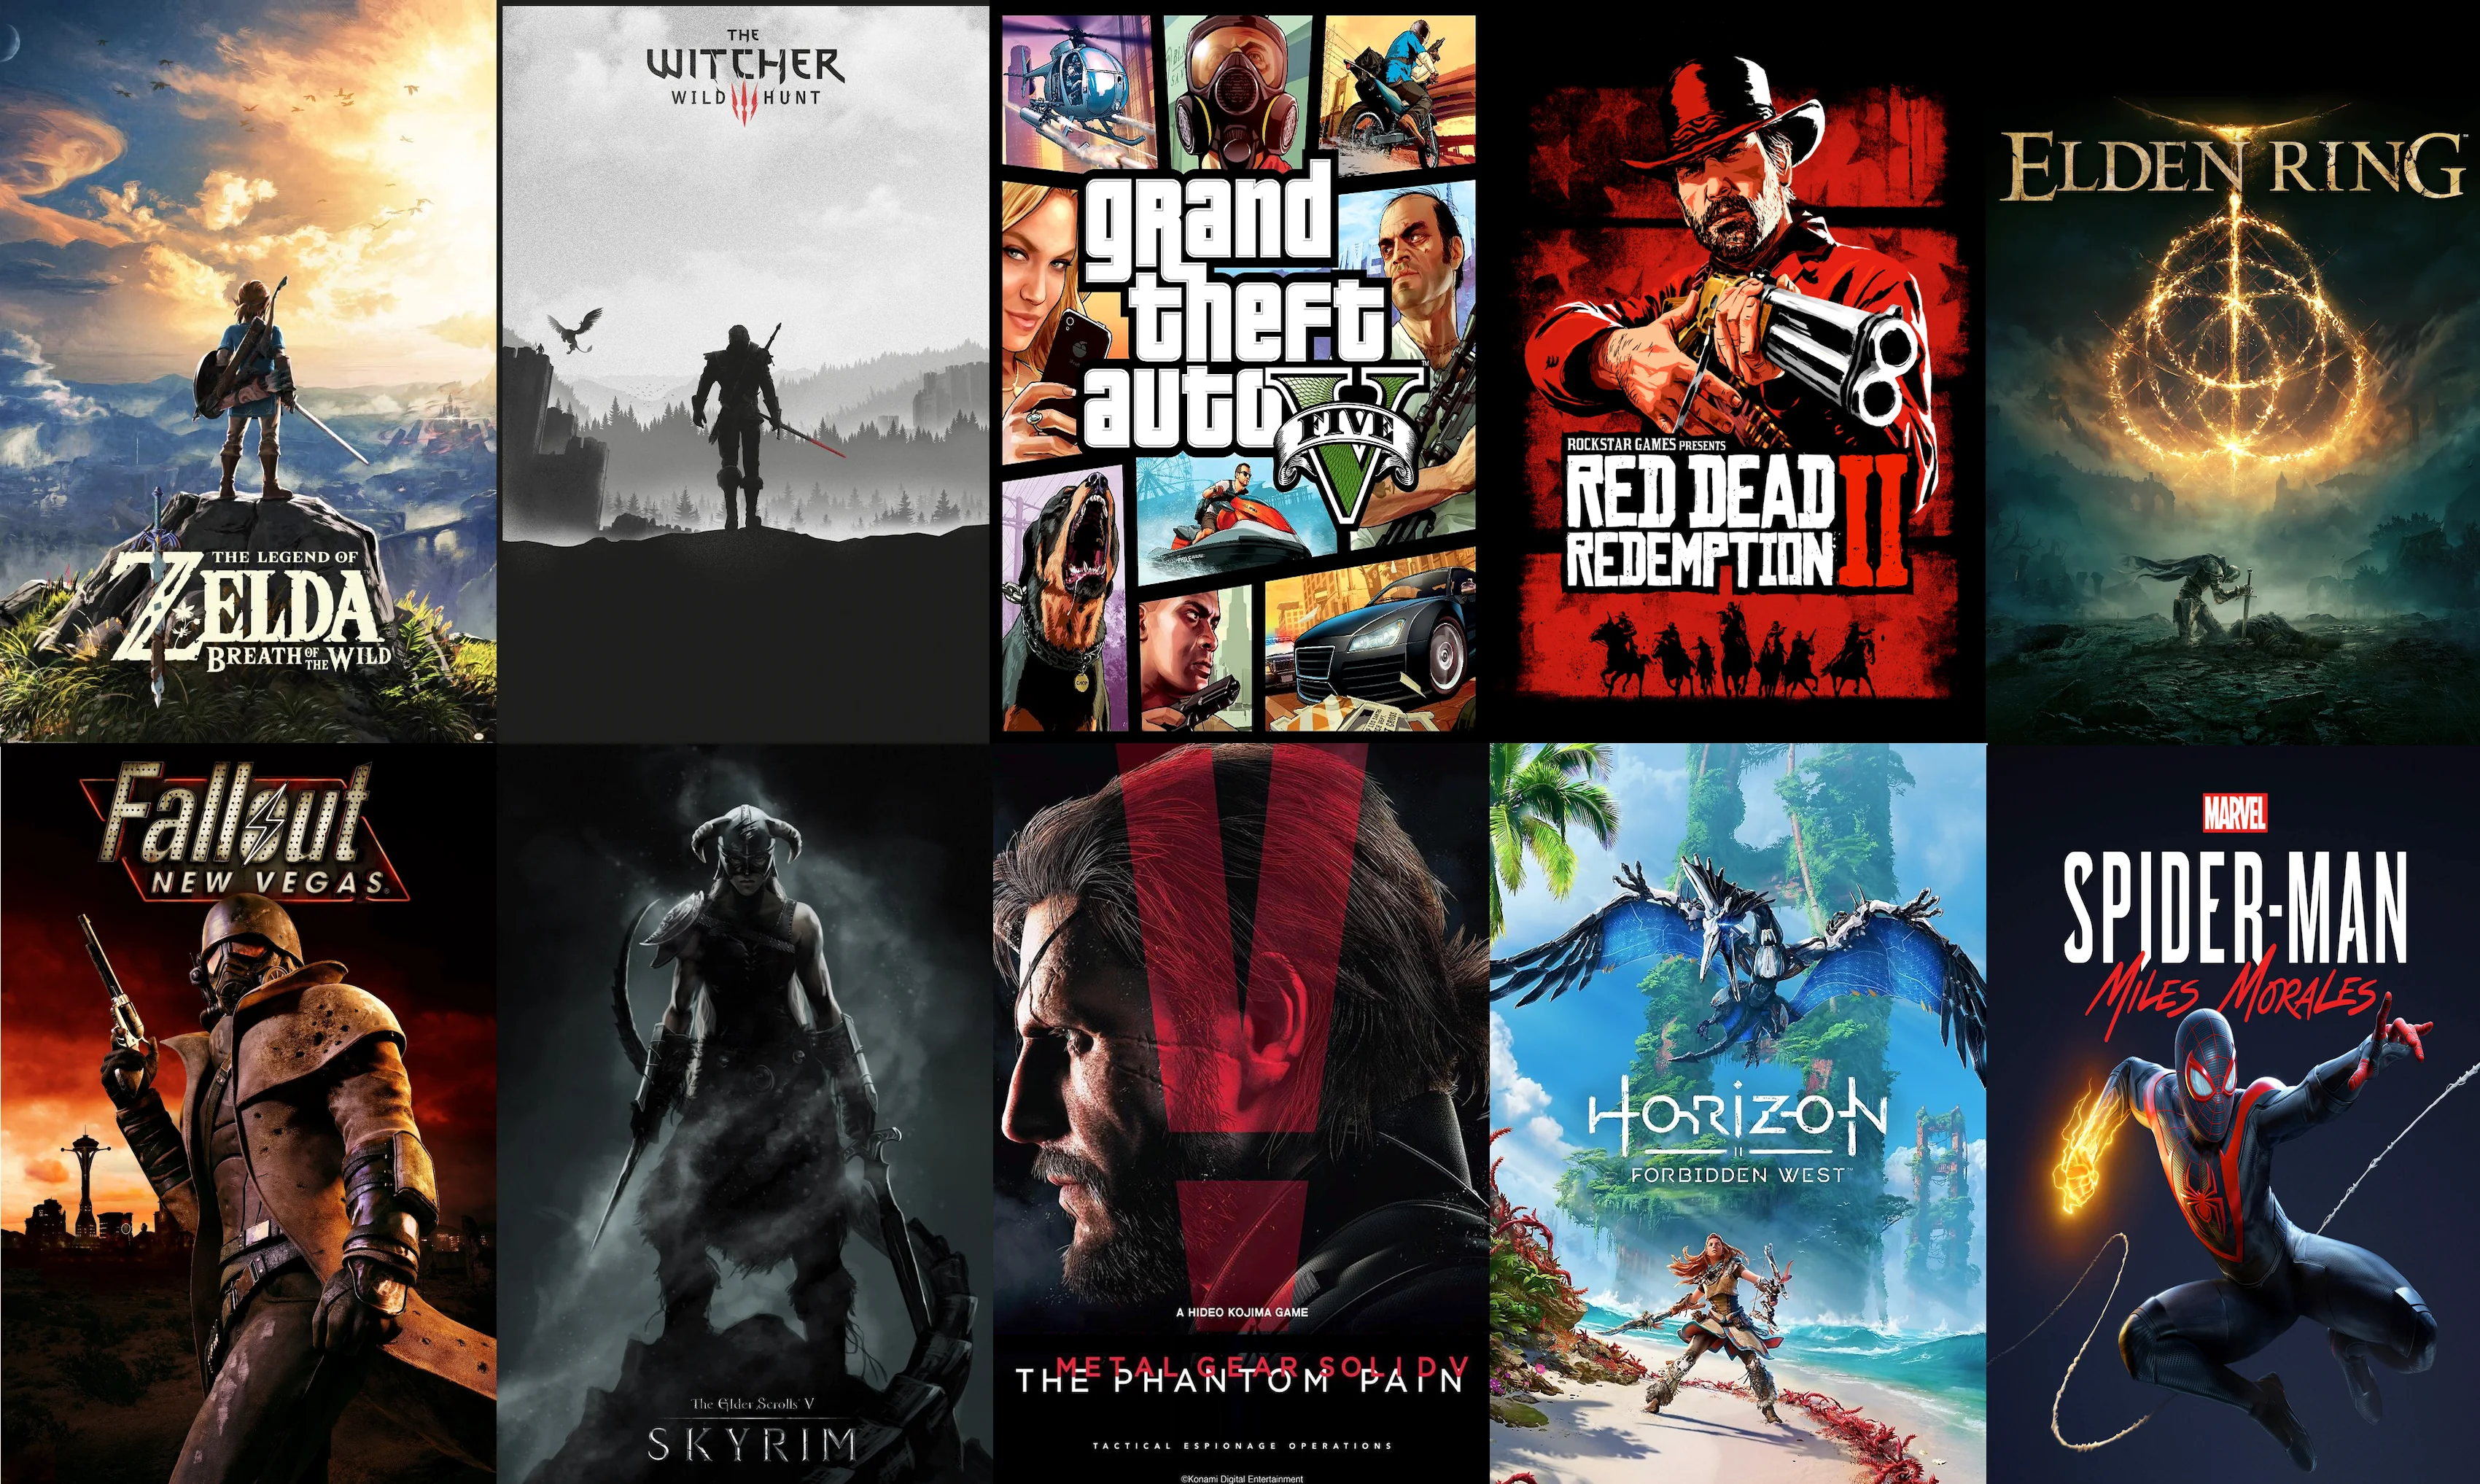

## ¿Cómo diseñamos un sistema que no solo copie, sino que "entienda" qué hace que un rostro humano parezca humano, para que pueda "imaginar" rostros nuevos y perfectos?

Es precisamente en estos escenarios donde las GAN (Generative Adversarial Networks) demuestran su verdadero potencial. Surgen como una solución crítica cuando nos enfrentamos a una escasez de datos reales o cuando el costo logístico y financiero de generar contenido nuevo —como modelar manualmente cientos de rostros únicos para un videojuego— resulta prohibitivo para cualquier equipo de desarrollo.

La gran ventaja competitiva de las GAN es su capacidad para generar datos sintéticos con un nivel de fidelidad asombroso. A diferencia de otros métodos de automatización, estas redes no solo replican patrones, sino que aprenden la estructura profunda de la información, permitiendo crear resultados con una calidad prácticamente indistinguible de la realidad.

## Ejemplo Resident Evil 2

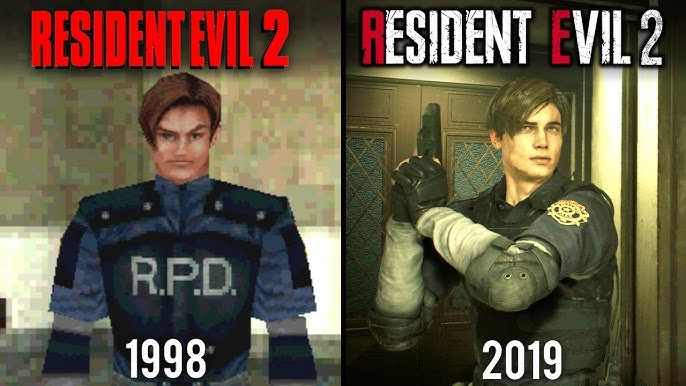

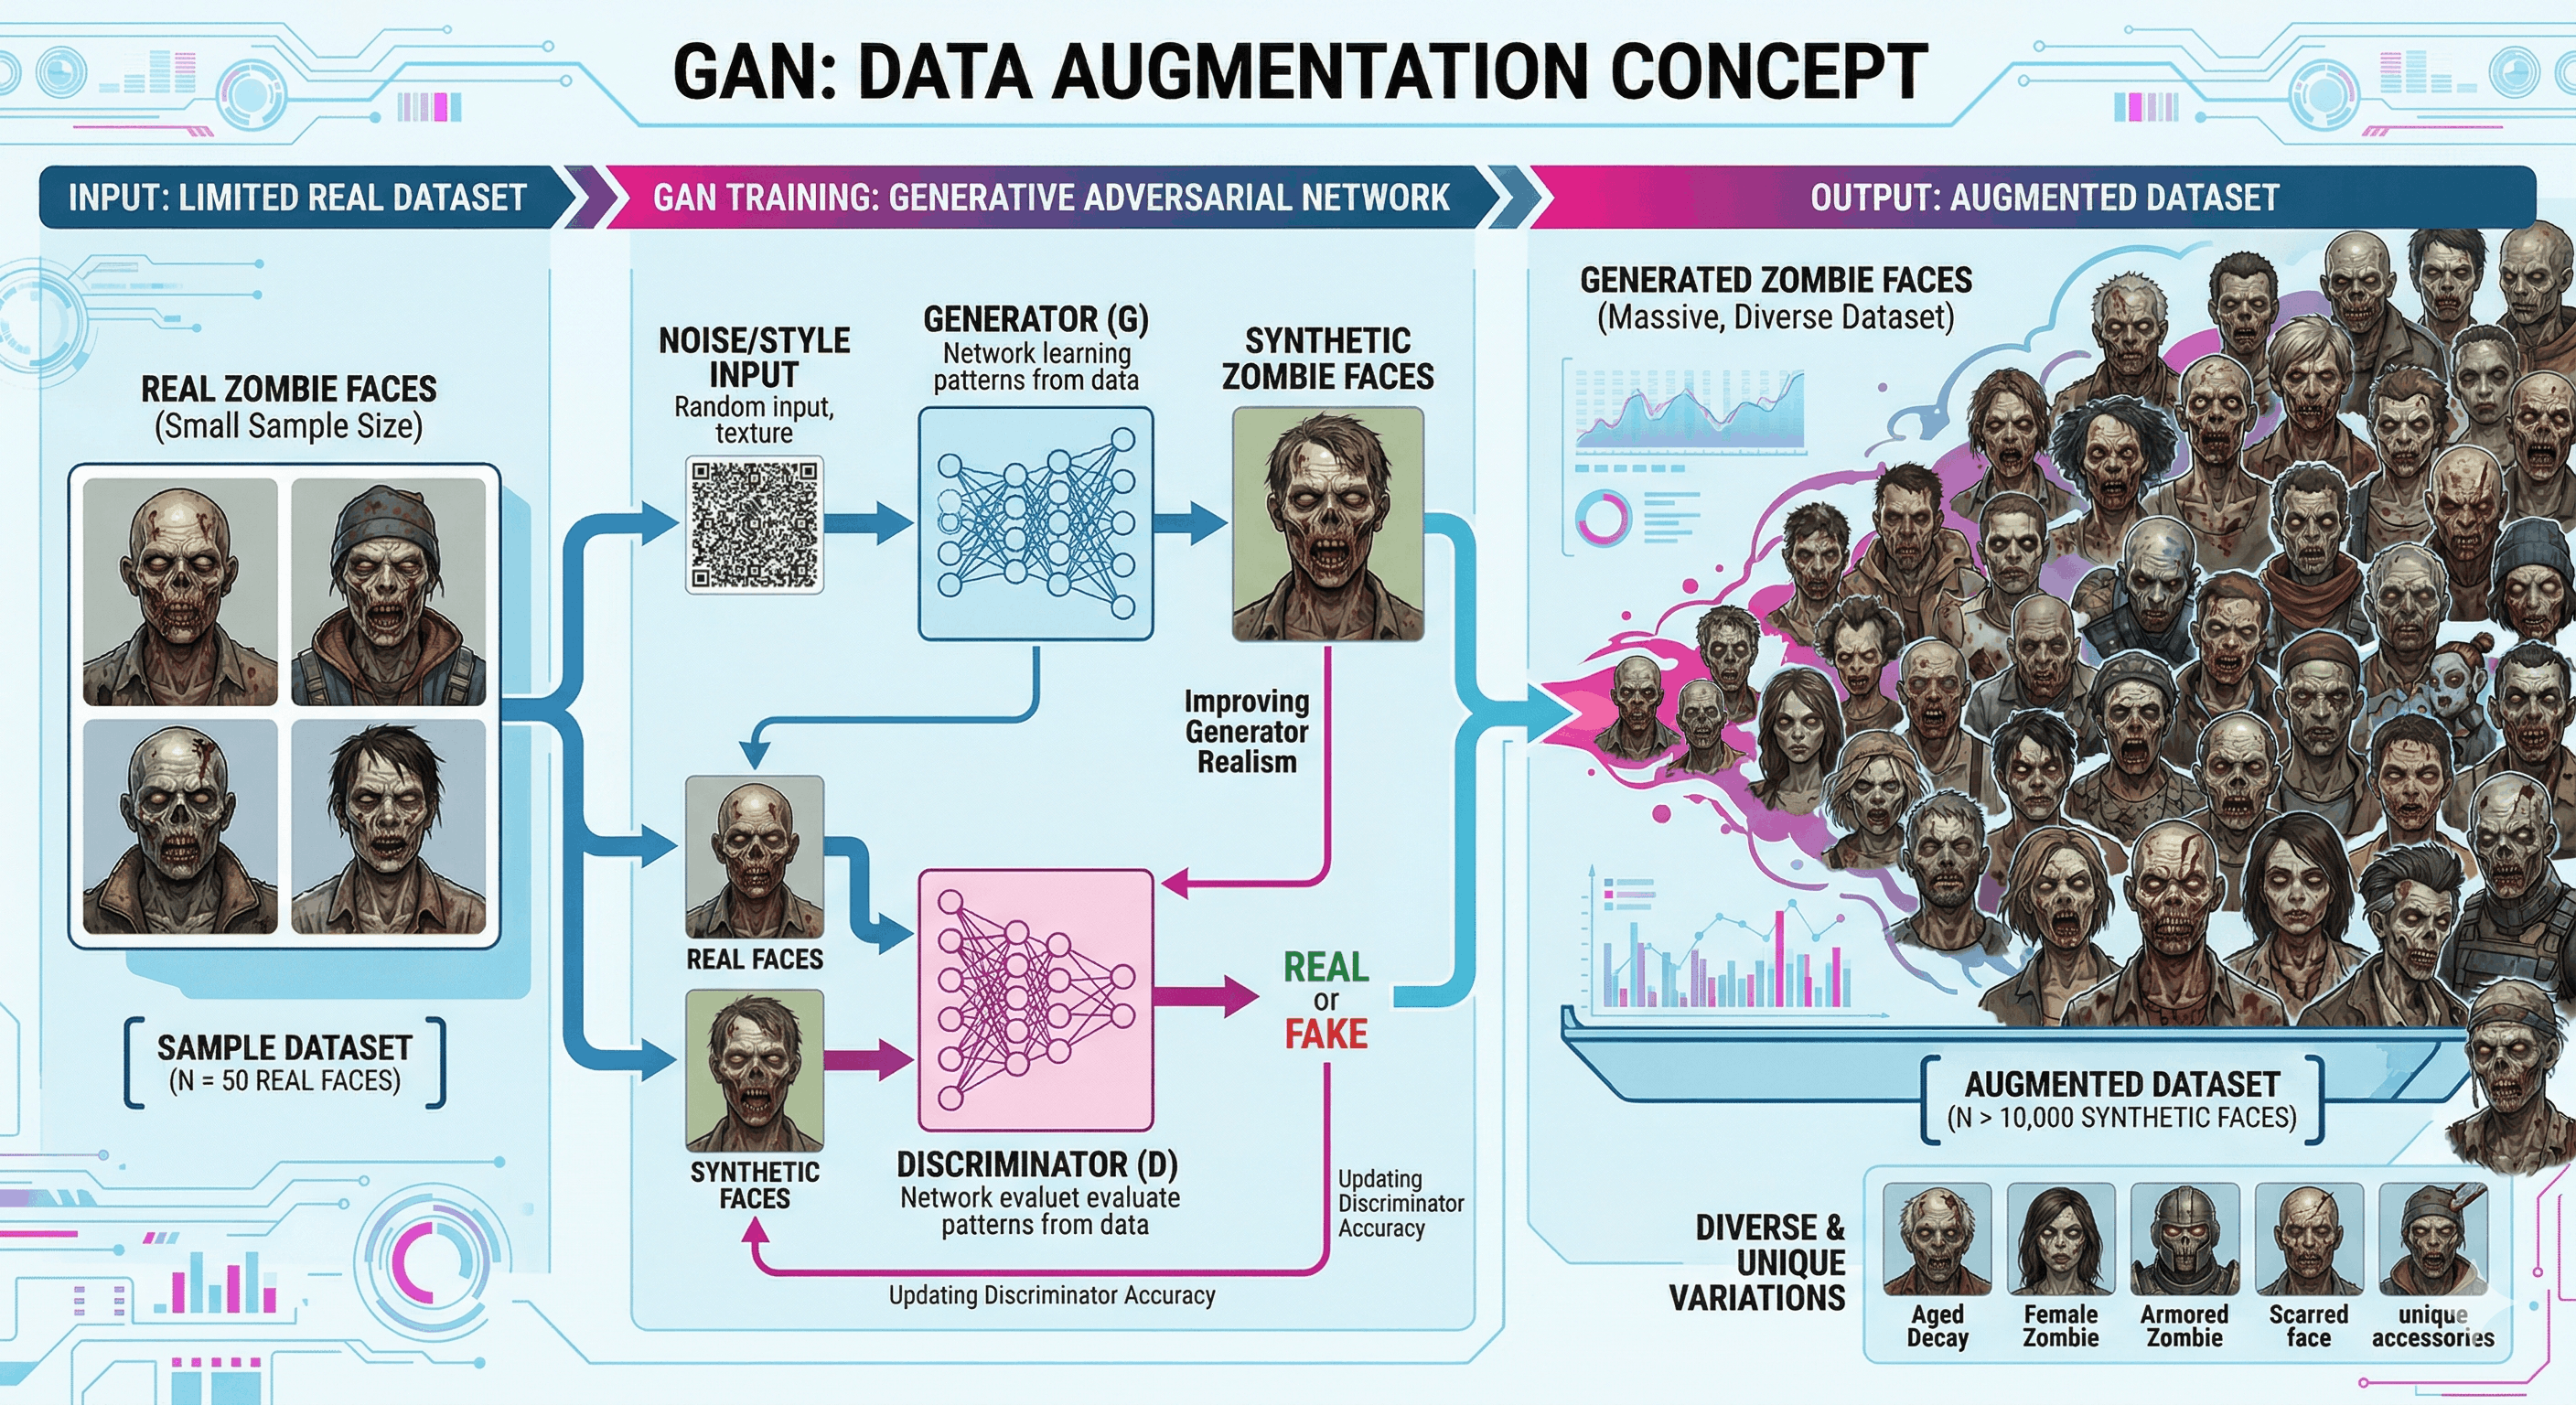

## Cómo funcionan?

### La Arquitectura GAN: El Falsificador vs. El Detective

Las GAN (Generative Adversarial Networks) se llaman "Antagónicas" o "Adversarias" porque están compuestas por **dos redes neuronales que compiten entre sí** en un juego constante del gato y el ratón.

#### 1. El Generador (El Falsificador)
* **Su trabajo:** Crear datos falsos (ej. dibujar la cara de un zombie inédito) a partir de ruido aleatorio y parámetros matemáticos.
* **Su objetivo:** Engañar al sistema para que crea que su creación es 100% real.

> Add blockquote


* **Al principio:** Es un novato. Sus primeros intentos son solo manchas borrosas de píxeles sin sentido.

#### 2. El Discriminador (El Detective)
* **Su trabajo:** Analizar una imagen y decidir si es del conjunto de datos original (zombies reales diseñados por los artistas) o si es una creación sintética del Generador.
* **Su objetivo:** Atrapar absolutamente todas las falsificaciones.
* **Al principio:** Conoce las imágenes reales de referencia, lo que es suficiente para atrapar las falsificaciones obvias del Generador.

---

### El Ciclo de Entrenamiento (Donde ocurre la magia)

El secreto del éxito de las GAN es el ciclo de retroalimentación y competencia constante entre ambas redes:

1. **El Intento:** El Generador crea una cara falsa y se la presenta al Detective.
2. **La Crítica:** El Detective la analiza, la rechaza y señala los errores: *"Esto es falso, los ojos están asimétricos y la piel no tiene textura real."* (En la práctica, le devuelve el cálculo del error matemático).
3. **El Aprendizaje:** El Generador usa esa crítica precisa para ajustar sus algoritmos internos y vuelve a intentarlo, mejorando su técnica en cada iteración.
4. **El Empate (Convergencia):** Eventualmente, el Generador se vuelve tan increíblemente bueno dibujando texturas, sombras y anatomía, que el Detective ya no puede notar la diferencia. Su tasa de acierto cae al 50%, lo que equivale a dudar y tener que lanzar una moneda al aire.

> **En ese momento, la red está lista para generar variaciones infinitas y fotorrealistas.**

# El Modelo Generador y el Modelo Discriminador

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

PyTorch: 2.10.0+cu128
CUDA disponible: True
Usando: cuda


## Cargando MNIST

Usamos MNIST: 60,000 imágenes de dígitos escritos a mano, 28×28 píxeles en escala de grises. Normalizamos a [-1, 1] porque el generador va a usar tanh como activación fina

In [ ]:
# Hiperparámetros globales
BATCH_SIZE  = 128
LATENT_DIM  = 100   # dimensión del vector de ruido z
LR          = 0.0002
BETAS       = (0.5, 0.999)  # Adam con momentum reducido (recomendado para GANs)
NUM_EPOCHS  = 50
IMG_SIZE    = 28
CHANNELS    = 1

# Transformaciones: redimensionar, a tensor, normalizar a [-1, 1]
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # (pixel - 0.5) / 0.5
])

# Descarga MNIST
dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Total imágenes: {len(dataset):,}")
print(f"Batches por epoch: {len(dataloader)}")
print(f"Forma de un batch: {next(iter(dataloader))[0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 353kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.45MB/s]

Total imágenes: 60,000
Batches por epoch: 469
Forma de un batch: torch.Size([128, 1, 28, 28])


## Generador

Toma un vector de ruido z de dimensión 100 y lo transforma en una imagen de 28×28. Cada capa aprende a "darle forma" al ruido:

Linear → BatchNorm → LeakyReLU: expande el vector de ruido

Reshape → ConvTranspose2d: convierte a imagen (upsampling)

Tanh al final: salida en rango [-1, 1], mismo que los datos reales

In [ ]:
class Generator(nn.Module):
    """
    Generador: z (100,) → imagen (1, 28, 28)

    Flujo:
      z                         [batch, 100]
      → Linear + BN + LReLU    [batch, 256]
      → Linear + BN + LReLU    [batch, 512]
      → Linear + BN + LReLU    [batch, 1024]
      → Linear + Tanh           [batch, 784]
      → Reshape                 [batch, 1, 28, 28]
    """

    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            # Bloque 1: z → 256
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),          # estabiliza el entrenamiento
            nn.LeakyReLU(0.2, inplace=True),

            # Bloque 2: 256 → 512
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # Bloque 3: 512 → 1024
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            # Capa final: 1024 → 784 píxeles
            nn.Linear(1024, 784),
            nn.Tanh()              # salida en [-1, 1], igual que los datos normalizados
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, 28, 28)  # reshape a imagen
        return img


G = Generator(LATENT_DIM).to(device)
print(G)
total_params = sum(p.numel() for p in G.parameters())
print(f"\nParámetros totales del Generador: {total_params:,}")

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

Parámetros totales del Generador: 1,489,936


## Discriminador

Toma una imagen de 28×28 y devuelve un escalar: la probabilidad de que la imagen sea real. Es básicamente un clasificador binario.

LeakyReLU en vez de ReLU: evita el problema de gradientes muertos

Dropout: regularización, evita que el discriminador sea demasiado bueno demasiado rápido

Sigmoid al final: salida en [0, 1] = probabilidad

In [ ]:
class Discriminator(nn.Module):
    """
    Discriminador: imagen (1, 28, 28) → probabilidad real [0, 1]

    Flujo:
      imagen                    [batch, 1, 28, 28]
      → Flatten                 [batch, 784]
      → Linear + LReLU + Drop  [batch, 512]
      → Linear + LReLU + Drop  [batch, 256]
      → Linear + Sigmoid        [batch, 1]
    """

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # Bloque 1: 784 → 512
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),              # evita overfitting del discriminador

            # Bloque 2: 512 → 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # Capa final: clasificación binaria
            nn.Linear(256, 1),
            nn.Sigmoid()               # P(real | imagen) ∈ [0, 1]
        )

    def forward(self, img):
        validity = self.model(img)
        return validity


D = Discriminator().to(device)
print(D)
total_params = sum(p.numel() for p in D.parameters())
print(f"\nParámetros totales del Discriminador: {total_params:,}")

Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=1, bias=True)
    (8): Sigmoid()
  )
)

Parámetros totales del Discriminador: 533,505


Ambas redes usan Binary Cross-Entropy. La diferencia está en qué etiquetas se usa para cada uno:

D con reales: quiere predecir 1.0 → loss = BCE(D(x_real), 1)

D con falsos: quiere predecir 0.0 → loss = BCE(D(G(z)), 0)

G: quiere que D prediga 1.0 en sus imágenes → loss = BCE(D(G(z)), 1)

Se usa Adam con β₁=0.5 (en vez de 0.9). El paper original de GAN recomienda esto para estabilidad

In [ ]:
# Función de pérdida: Binary Cross-Entropy
adversarial_loss = nn.BCELoss()

# Optimizadores separados para G y D
optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

# Ruido fijo para visualizar progreso consistente
fixed_noise = torch.randn(64, LATENT_DIM, device=device)

print("✓ Loss function: BCELoss")
print("✓ Optimizer G: Adam (lr=0.0002, β₁=0.5)")
print("✓ Optimizer D: Adam (lr=0.0002, β₁=0.5)")
print(f"✓ Fixed noise shape: {fixed_noise.shape}")

✓ Loss function: BCELoss
✓ Optimizer G: Adam (lr=0.0002, β₁=0.5)
✓ Optimizer D: Adam (lr=0.0002, β₁=0.5)
✓ Fixed noise shape: torch.Size([64, 100])


## Entrenamiento de Cada Modelo

Cada batch de entrenamiento tiene dos fases:

Fase 1 — Entrenar D: se le muestra imágenes reales (etiqueta 1) y falsas (etiqueta 0), y se actualiza solo los pesos de D

Fase 2 — Entrenar G: se genera imágenes falsas, y se le pide a D que las evalúe, pero se quiere que D diga 1 (real).

Solo se actualiza pesos de G

Importante: cuando se entrena G, "se congela" D (no se actualizan sus gradientes). Cada uno aprende de su propio error.

In [ ]:
# Historial de métricas
history = {"d_loss": [], "g_loss": [], "d_real": [], "d_fake": []}
sample_images = []

for epoch in range(NUM_EPOCHS):
    epoch_d_loss = 0
    epoch_g_loss = 0
    epoch_d_real = 0
    epoch_d_fake = 0

    for batch_idx, (real_imgs, _) in enumerate(dataloader):
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # ─── Etiquetas ────────────────────────────────────────────
        real_label = torch.ones(batch_size, 1, device=device)   # 1 = real
        fake_label = torch.zeros(batch_size, 1, device=device)  # 0 = falso

        # ═══════════════════════════════════════════════════════════
        # FASE 1: Entrenar el DISCRIMINADOR
        # Objetivo: D(real) → 1   y   D(G(z)) → 0
        # ═══════════════════════════════════════════════════════════
        optimizer_D.zero_grad()  # limpiar gradientes anteriores

        # 1a. Pérdida con imágenes reales
        real_output = D(real_imgs)                          # D evalúa reales
        d_loss_real = adversarial_loss(real_output, real_label)  # quiere predecir 1

        # 1b. Generar imágenes falsas (G no se actualiza aquí)
        z = torch.randn(batch_size, LATENT_DIM, device=device)  # ruido
        fake_imgs = G(z).detach()  # .detach() = no propagar gradientes a G

        # 1c. Pérdida con imágenes falsas
        fake_output = D(fake_imgs)                          # D evalúa falsos
        d_loss_fake = adversarial_loss(fake_output, fake_label)  # quiere predecir 0

        # 1d. Loss total del Discriminador y actualizar pesos
        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        optimizer_D.step()

        # ═══════════════════════════════════════════════════════════
        # FASE 2: Entrenar el GENERADOR
        # Objetivo: que D(G(z)) → 1  (engañar al discriminador)
        # ═══════════════════════════════════════════════════════════
        optimizer_G.zero_grad()  # limpiar gradientes anteriores

        # 2a. Generar imágenes nuevas (ahora SÍ queremos gradientes)
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        gen_imgs = G(z)                                     # imágenes generadas

        # 2b. D evalúa las imágenes, pero G quiere que D diga "real" (1)
        g_output = D(gen_imgs)
        g_loss = adversarial_loss(g_output, real_label)

        # 2c. Actualizar pesos del Generador (D NO se toca)
        g_loss.backward()
        optimizer_G.step()

        # ─── Acumular métricas ─────────────────────────────────────
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_d_real += real_output.mean().item()  # D(x): cuánto le cree a los reales
        epoch_d_fake += fake_output.mean().item()  # D(G(z)): cuánto le cree a los falsos

    # ─── Log por epoch ─────────────────────────────────────────
    n = len(dataloader)
    history["d_loss"].append(epoch_d_loss / n)
    history["g_loss"].append(epoch_g_loss / n)
    history["d_real"].append(epoch_d_real / n)
    history["d_fake"].append(epoch_d_fake / n)

    # Guardar imágenes de muestra cada 10 epochs
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            sample = G(fixed_noise).cpu()
        sample_images.append((epoch + 1, sample))

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
              f"D loss: {history['d_loss'][-1]:.4f} | "
              f"G loss: {history['g_loss'][-1]:.4f} | "
              f"D(x): {history['d_real'][-1]:.4f} | "
              f"D(G(z)): {history['d_fake'][-1]:.4f}")

Epoch [5/50] | D loss: 0.6115 | G loss: 0.9915 | D(x): 0.5763 | D(G(z)): 0.4371
Epoch [10/50] | D loss: 0.6414 | G loss: 0.8588 | D(x): 0.5494 | D(G(z)): 0.4572
Epoch [15/50] | D loss: 0.6534 | G loss: 0.8300 | D(x): 0.5381 | D(G(z)): 0.4643
Epoch [20/50] | D loss: 0.6619 | G loss: 0.8055 | D(x): 0.5308 | D(G(z)): 0.4701
Epoch [25/50] | D loss: 0.6688 | G loss: 0.7848 | D(x): 0.5246 | D(G(z)): 0.4760
Epoch [30/50] | D loss: 0.6738 | G loss: 0.7753 | D(x): 0.5205 | D(G(z)): 0.4792
Epoch [35/50] | D loss: 0.6760 | G loss: 0.7660 | D(x): 0.5182 | D(G(z)): 0.4813
Epoch [40/50] | D loss: 0.6775 | G loss: 0.7587 | D(x): 0.5170 | D(G(z)): 0.4834
Epoch [45/50] | D loss: 0.6780 | G loss: 0.7541 | D(x): 0.5164 | D(G(z)): 0.4844
Epoch [50/50] | D loss: 0.6797 | G loss: 0.7510 | D(x): 0.5141 | D(G(z)): 0.4855


Se usa el mismo fixed_noise en cada checkpoint para ver cómo el generador mejora con el tiempo. Esto  permite comparar directamente el mismo "concepto" en distintas etapas del entrenamiento.

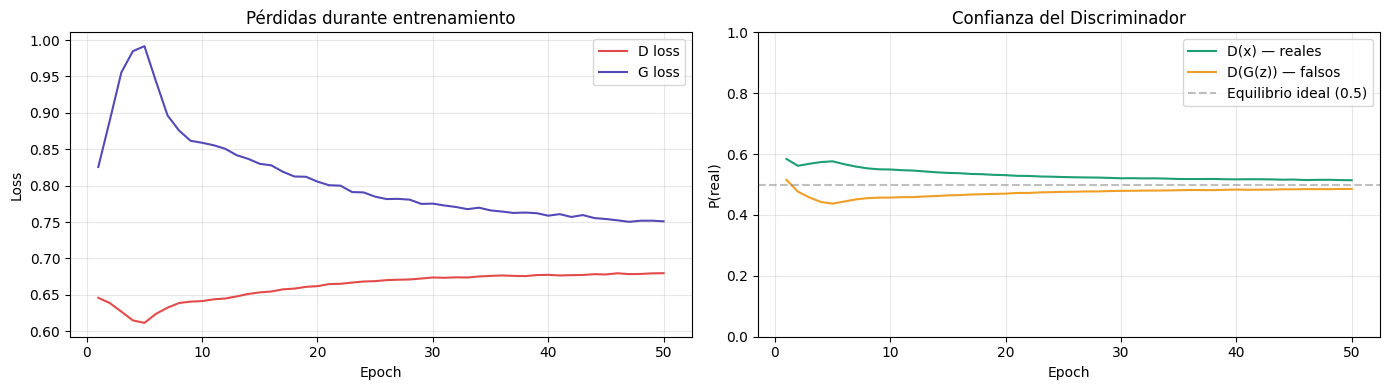

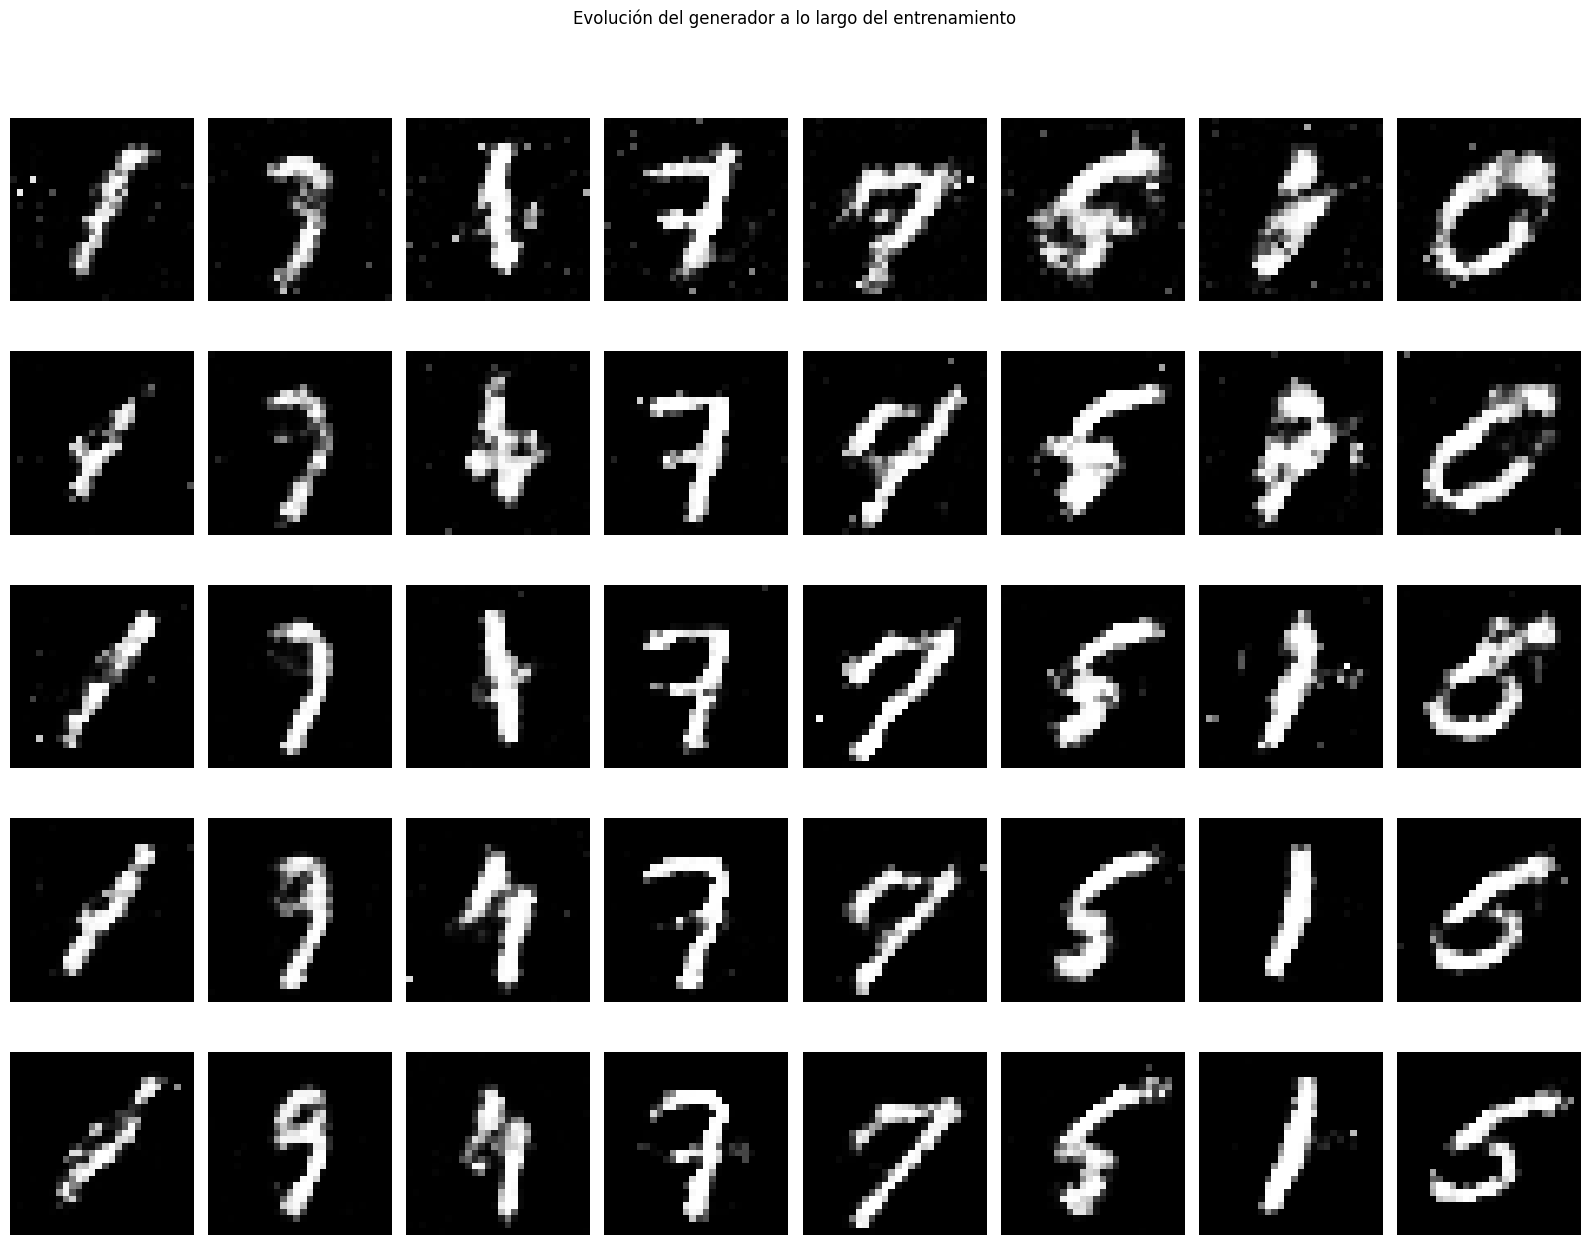

In [ ]:
def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Gráfica 1: Losses
    epochs = range(1, len(history["d_loss"]) + 1)
    axes[0].plot(epochs, history["d_loss"], label="D loss", color="#E24B4A")
    axes[0].plot(epochs, history["g_loss"], label="G loss", color="#534AB7")
    axes[0].set_title("Pérdidas durante entrenamiento")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Gráfica 2: D(x) vs D(G(z))
    axes[1].plot(epochs, history["d_real"], label="D(x) — reales",  color="#1D9E75")
    axes[1].plot(epochs, history["d_fake"], label="D(G(z)) — falsos", color="#EF9F27")
    axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Equilibrio ideal (0.5)")
    axes[1].set_title("Confianza del Discriminador")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("P(real)")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

# Visualizar imágenes generadas en distintos checkpoints
fig, axes = plt.subplots(len(sample_images), 8, figsize=(16, 2.5 * len(sample_images)))

for row, (ep, imgs) in enumerate(sample_images):
    for col in range(8):
        axes[row, col].imshow(imgs[col].squeeze(), cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(f"Epoch {ep}", fontsize=10)

plt.suptitle("Evolución del generador a lo largo del entrenamiento", y=1.02)
plt.tight_layout()
plt.show()

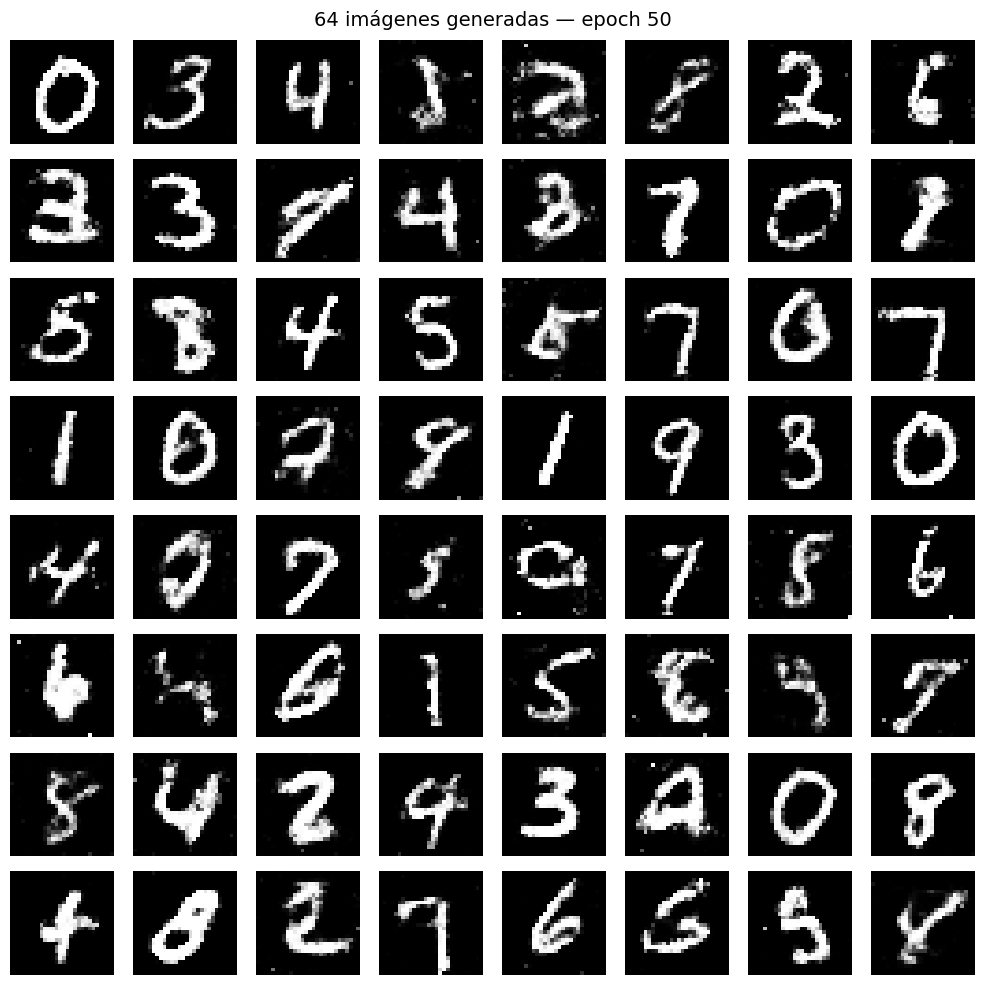

Resumen del entrenamiento:
  • D loss final:  0.6797
  • G loss final:  0.7510
  • D(x) final:    0.5141  (ideal: 0.5)
  • D(G(z)) final: 0.4855  (ideal: 0.5)

  → El discriminador aún domina (D(x)≈0.92 vs D(G(z))≈0.14)
  → El pivote demostrará cómo solucionar esto


In [ ]:
# Generar una grilla de 64 imágenes con ruido nuevo
with torch.no_grad():
    test_noise = torch.randn(64, LATENT_DIM, device=device)
    generated = G(test_noise).cpu()

# Desnormalizar de [-1,1] a [0,1]
generated = (generated + 1) / 2

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("64 imágenes generadas — epoch 50", fontsize=14)
plt.tight_layout()
plt.show()

print("Resumen del entrenamiento:")
print(f"  • D loss final:  {history['d_loss'][-1]:.4f}")
print(f"  • G loss final:  {history['g_loss'][-1]:.4f}")
print(f"  • D(x) final:    {history['d_real'][-1]:.4f}  (ideal: 0.5)")
print(f"  • D(G(z)) final: {history['d_fake'][-1]:.4f}  (ideal: 0.5)")

## Real vs Generado

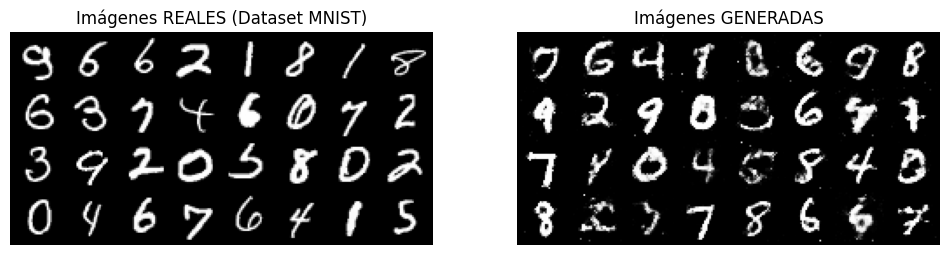

In [ ]:
# Celda para comparar Real vs Generado
import torchvision

# 1. Obtener un batch de imágenes REALES
dataiter = iter(dataloader)
real_batch, _ = next(dataiter)

# 2. Generar un batch de imágenes FALSAS con el modelo entrenado
G.eval() # Modo evaluación
with torch.no_grad():
    z = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)
    fake_batch = G(z).cpu()

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar Reales
grid_real = torchvision.utils.make_grid(real_batch[:32], nrow=8, normalize=True)
ax[0].imshow(grid_real.permute(1, 2, 0).numpy(), cmap='gray')
ax[0].set_title("Imágenes REALES (Dataset MNIST)")
ax[0].axis('off')

# Mostrar Generadas
grid_fake = torchvision.utils.make_grid(fake_batch[:32], nrow=8, normalize=True)
ax[1].imshow(grid_fake.permute(1, 2, 0).numpy(), cmap='gray')
ax[1].set_title("Imágenes GENERADAS")
ax[1].axis('off')

plt.show()

# Dificultades de las GAN

Aunque el generador y el discriminador ya funcionan a nivel básico, el entrenamiento de una GAN es inherentemente inestable. A diferencia de los modelos de aprendizaje automático tradicionales que buscan minimizar una función de pérdida única, una GAN es un **juego de suma cero** entre dos redes neuronales que compiten. Esta naturaleza adversaria significa que no hay un punto de convergencia 'estable' en el sentido clásico, ya que el objetivo de uno es contrarrestar al otro constantemente. El equilibrio es dinámico y frágil.

## Inestabilidad del entrenamiento

Las GANs no convergen de forma clara, a menudo sus pérdidas oscilan salvajemente, y una red puede dominar a la otra fácilmente.

La naturaleza competitiva de las GANs lleva a un entrenamiento volátil. Es común observar que las funciones de pérdida del Generador y del Discriminador no descienden suavemente hacia un mínimo, sino que presentan fluctuaciones y oscilaciones. Esto se debe a que, a medida que el Generador mejora, el Discriminador se vuelve más exigente, y viceversa. Si una red se vuelve demasiado fuerte o demasiado débil en relación con la otra, el entrenamiento puede estancarse o colapsar. Por ejemplo, un Discriminador muy potente puede 'ganar' tan fácilmente que el Generador recibe gradientes débiles, impidiéndole aprender; o un Generador demasiado exitoso puede engañar tanto al Discriminador que este deja de proporcionar retroalimentación útil.

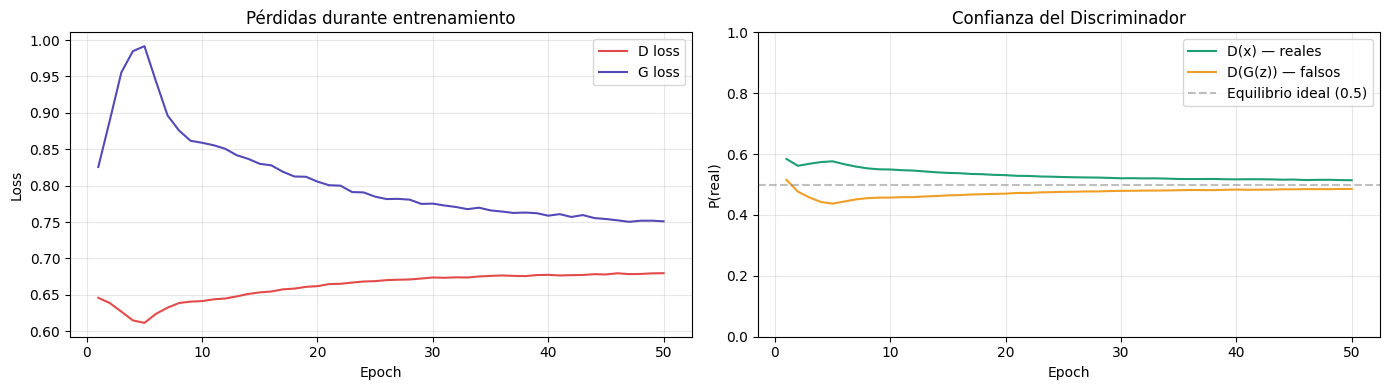

In [ ]:
plot_training_curves(history)

### Análisis de Inestabilidad

Los gráficos muestran que las pérdidas del Generador (G loss) y del Discriminador (D loss) no descienden suavemente a un mínimo, sino que oscilan, lo cual es característico de la inestabilidad en el entrenamiento de las GANs. Además, el Discriminador a menudo mantiene una confianza superior a 0.5 para las imágenes falsas (D(G(z))), indicando que aún puede distinguirlas de las reales, lo que sugiere que el Generador no ha logrado engañarlo consistentemente.

## Las métricas clásicas no funcionan de la misma manera

Un valor de pérdida 'bueno' no siempre se correlaciona con la calidad de las imágenes generadas; la evaluación visual sigue siendo crucial.
En las GANs, las métricas de pérdida tradicionales (como la Binary Cross-Entropy que usamos) pueden ser engañosas. Una pérdida baja para el Generador o Discriminador no garantiza que las imágenes generadas sean realistas o diversas. A menudo, el Generador puede encontrar "trucos" para reducir su pérdida sin realmente mejorar la calidad visual de las salidas, o el Discriminador puede estar atascado en un mínimo local. Por lo tanto, la inspección visual de las imágenes generadas por el modelo es una forma indispensable y, a menudo, la más reveladora para evaluar el progreso y el éxito del entrenamiento.

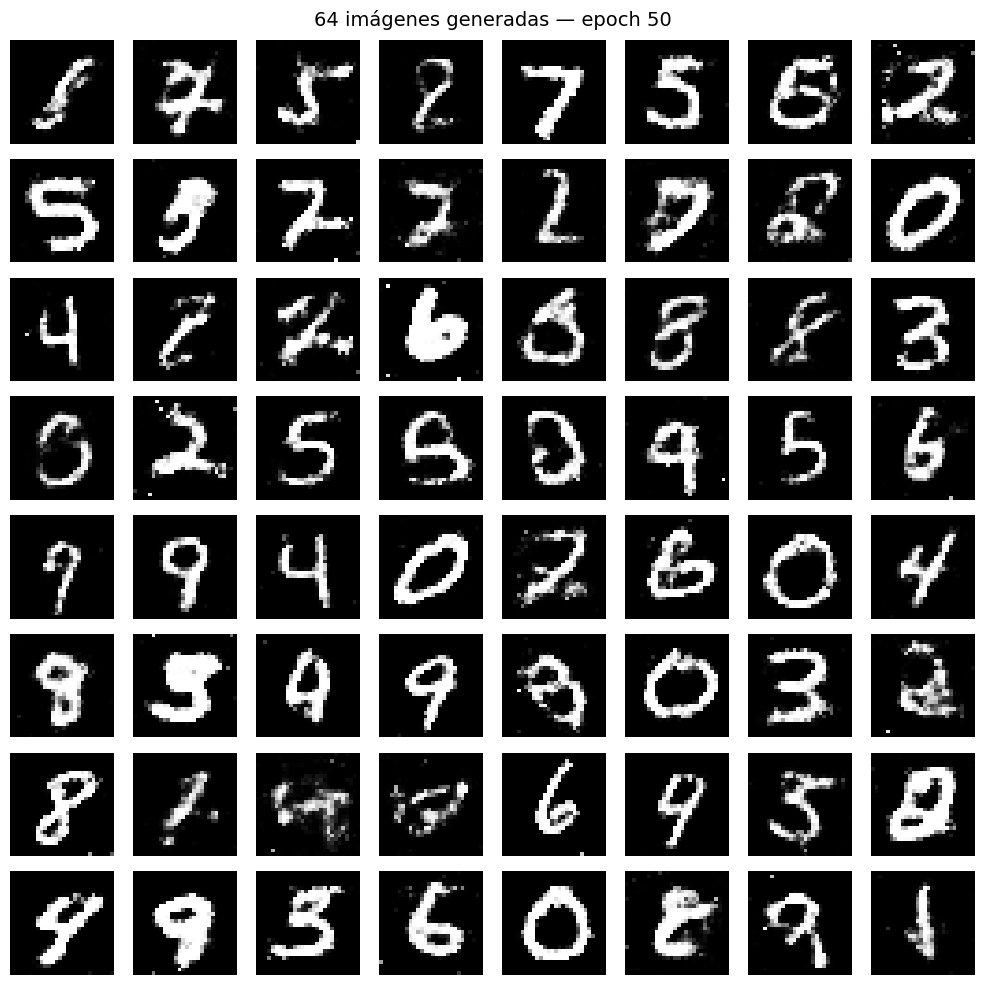


Resumen del entrenamiento (última epoch):
  • D loss final:  0.6797
  • G loss final:  0.7510
  • D(x) final:    0.5141  (ideal: 0.5)
  • D(G(z)) final: 0.4855  (ideal: 0.5)


In [ ]:
# Reutilizamos la visualización de imágenes generadas y la comparación con el loss final

# Generar una grilla de 64 imágenes con ruido nuevo
with torch.no_grad():
    test_noise = torch.randn(64, LATENT_DIM, device=device)
    generated = G(test_noise).cpu()

# Desnormalizar de [-1,1] a [0,1]
generated = (generated + 1) / 2

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("64 imágenes generadas — epoch 50", fontsize=14)
plt.tight_layout()
plt.show()

print("\nResumen del entrenamiento (última epoch):")
print(f"  • D loss final:  {history['d_loss'][-1]:.4f}")
print(f"  • G loss final:  {history['g_loss'][-1]:.4f}")
print(f"  • D(x) final:    {history['d_real'][-1]:.4f}  (ideal: 0.5)")
print(f"  • D(G(z)) final: {history['d_fake'][-1]:.4f}  (ideal: 0.5)")

Aunque los valores finales de D loss y G loss son ~0.6-0.7, y D(G(z)) se acerca a 0.5, las imágenes generadas, a pesar de mostrar formas rudimentarias, no son completamente realistas. Esto demuestra que un valor de pérdida 'aceptable' no siempre se traduce en imágenes de alta calidad, y la evaluación visual sigue siendo crucial.

## Mode Collapse

El generador produce un conjunto limitado de ejemplos muy similares, ignorando la rica diversidad de la distribución de datos real. El 'Mode Collapse' es un problema común donde el Generador, en lugar de aprender a producir la amplia variedad de datos presentes en el conjunto de entrenamiento, se centra en generar solo un subconjunto limitado de ejemplos que son fáciles de crear y que consistentemente engañan al Discriminador. Esto resulta en una falta de diversidad en las imágenes generadas; por ejemplo, si estamos generando rostros, podría producir solo unos pocos tipos de rostros en lugar de una gama completa de expresiones, edades y características. El Generador evita las partes "difíciles" de la distribución de datos, lo que empobrece la capacidad creativa de la GAN.

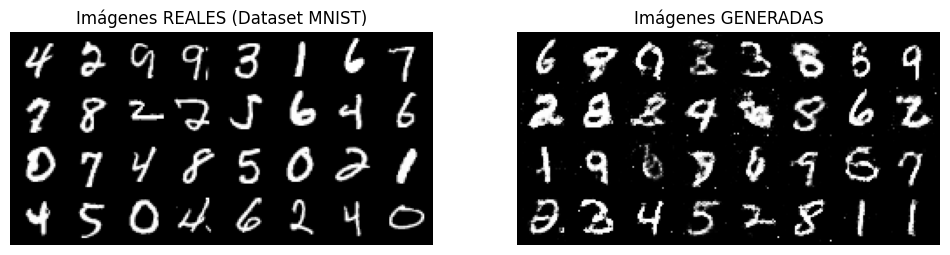

In [ ]:
# Reutilizamos la celda de comparación de imágenes reales vs generadas para observar la diversidad
import torchvision

# 1. Obtener un batch de imágenes REALES
dataiter = iter(dataloader)
real_batch, _ = next(dataiter)

# 2. Generar un batch de imágenes FALSAS con el modelo entrenado
G.eval() # Modo evaluación
with torch.no_grad():
    z = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)
    fake_batch = G(z).cpu()

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar Reales
grid_real = torchvision.utils.make_grid(real_batch[:32], nrow=8, normalize=True)
ax[0].imshow(grid_real.permute(1, 2, 0).numpy(), cmap='gray')
ax[0].set_title("Imágenes REALES (Dataset MNIST)")
ax[0].axis('off')

# Mostrar Generadas
grid_fake = torchvision.utils.make_grid(fake_batch[:32], nrow=8, normalize=True)
ax[1].imshow(grid_fake.permute(1, 2, 0).numpy(), cmap='gray')
ax[1].set_title("Imágenes GENERADAS")
ax[1].axis('off')

plt.show()

Al observar las imágenes generadas por nuestro modelo (derecha), podemos ver una falta de diversidad en comparación con las imágenes reales del dataset MNIST (izquierda). Aunque se generan diferentes 'dígitos', la variación dentro de cada dígito o la representación de todos los posibles estilos es limitada. Esto es un indicio de 'Mode Collapse', donde el Generador se enfoca en un subconjunto pequeño de la distribución de datos en lugar de aprender toda la variedad.

## Evolución del generador

La mejora del Generador durante el entrenamiento de una GAN es un proceso a menudo errático. Las imágenes generadas pueden pasar de ser ruido a formas reconocibles, pero esta progresión no es una línea recta. Es posible observar que, tras un período de mejora, la calidad de las imágenes se estanque, o incluso empeore en épocas posteriores, antes de volver a mejorar. Esta volatilidad es otra manifestación de la inestabilidad en el entrenamiento adversario, donde el Generador y el Discriminador se ajustan mutuamente en un ciclo que puede no ser siempre óptimo y monótono en su mejora.

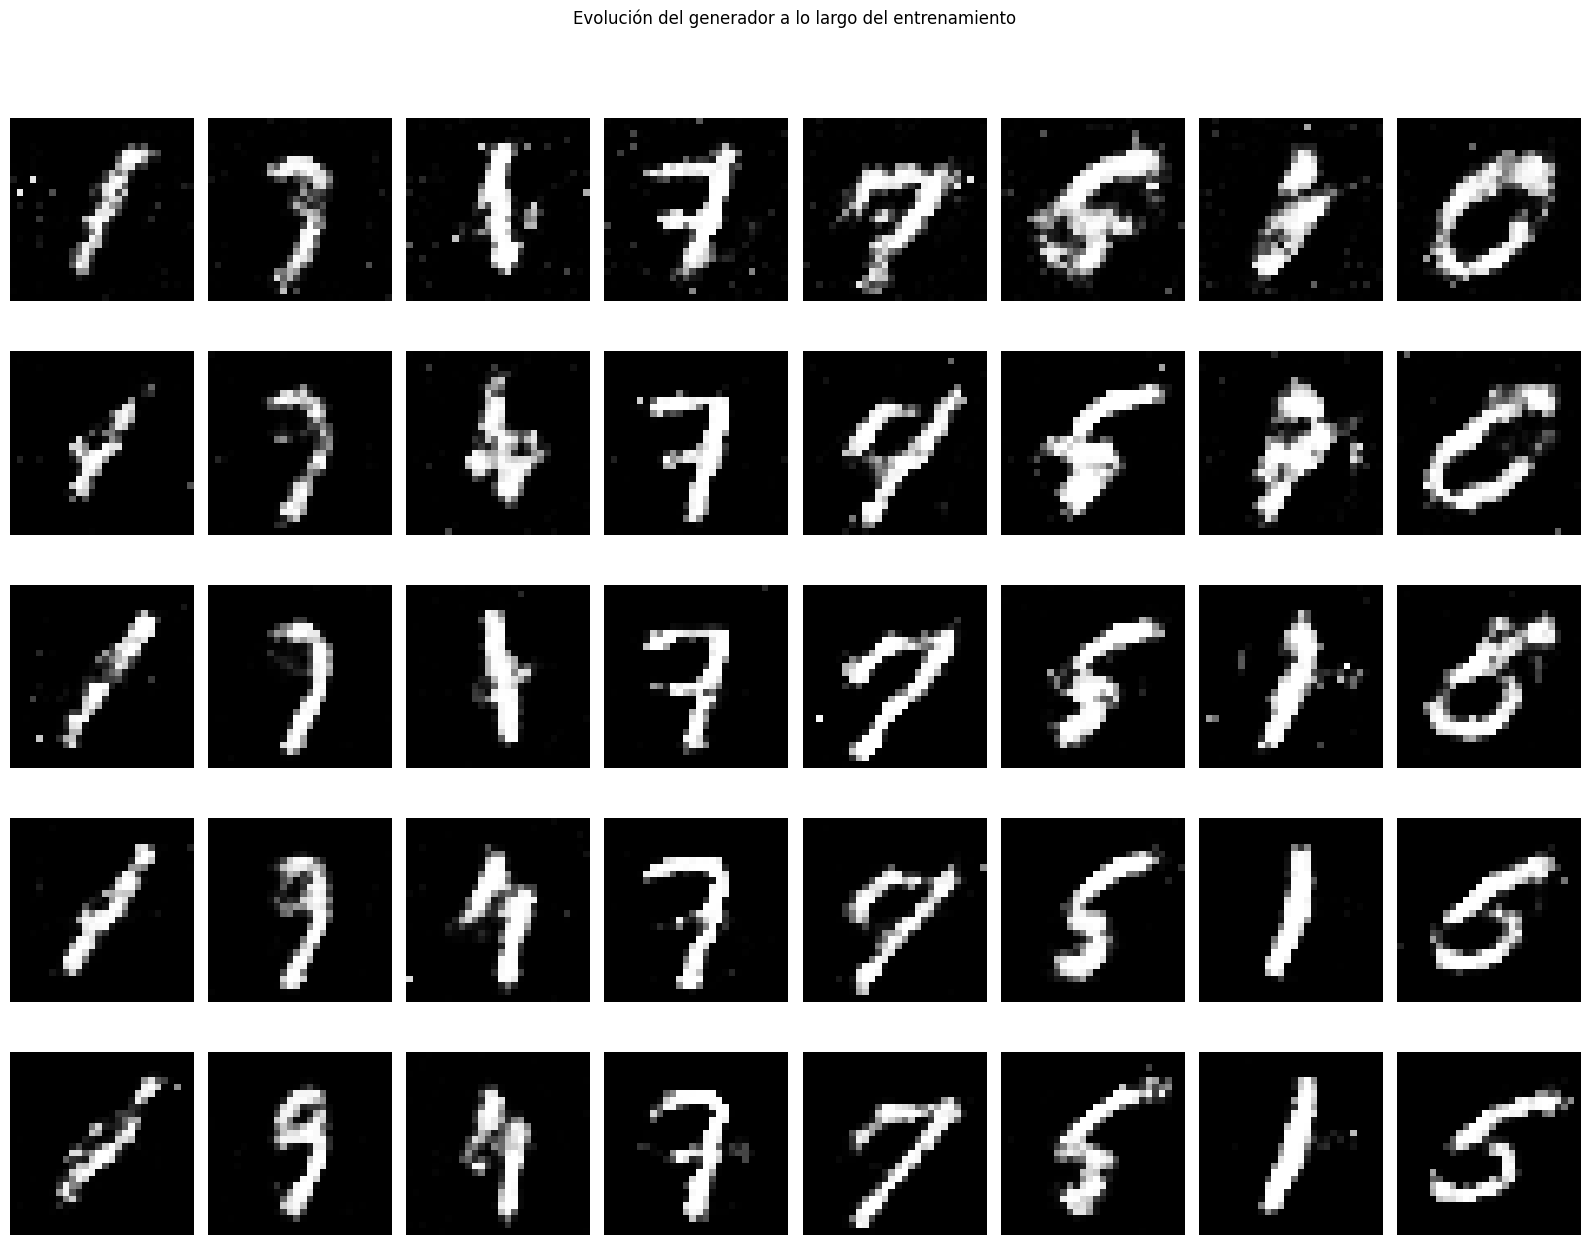

In [ ]:
# Visualizar imágenes generadas en distintos checkpoints (reutilizando código)
fig, axes = plt.subplots(len(sample_images), 8, figsize=(16, 2.5 * len(sample_images)))

for row, (ep, imgs) in enumerate(sample_images):
    for col in range(8):
        axes[row, col].imshow(imgs[col].squeeze(), cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(f"Epoch {ep}", fontsize=10)

plt.suptitle("Evolución del generador a lo largo del entrenamiento", y=1.02)
plt.tight_layout()
plt.show()

Las imágenes anteriores muestran la progresión del Generador en diferentes épocas (cada 10 épocas). Se observa cómo las formas iniciales (ruido) empiezan a asemejarse a dígitos, pero el proceso no es lineal. En algunos puntos, la calidad puede parecer estancada o incluso degradarse ligeramente antes de mejorar de nuevo. Esto ilustra la naturaleza inestable y no siempre monótona del entrenamiento de GANs.

## Sensibilidad

El rendimiento de las Redes Generativas Antagónicas es notoriamente sensible a la configuración de sus hiperparámetros. Variaciones mínimas en la tasa de aprendizaje (learning rate) para el Generador o el Discriminador, el tamaño del batch, las funciones de activación, la inicialización de los pesos, o incluso el número de pasos de entrenamiento para cada red, pueden tener un impacto masivo. Un conjunto de hiperparámetros que funciona bien en un escenario puede llevar al colapso total o a la generación de ruido constante en otro. Esto hace que la búsqueda de la configuración óptima sea un desafío considerable y a menudo requiere una experimentación exhaustiva.

## ¿Qué podemos hacer para Solucionarlo?

**Idea clave:** Dada la naturaleza compleja e inestable de las GANs y las limitaciones de las métricas tradicionales, se hace imperativo el uso de métricas de evaluación especializadas.
**Explicación:** Las dificultades y peculiaridades en el entrenamiento de las GANs, como la inestabilidad, el mode collapse y la falta de correlación directa entre la pérdida y la calidad visual, hacen que las métricas de evaluación clásicas sean insuficientes. Para obtener una comprensión más profunda y cuantitativa del rendimiento de una GAN, especialmente en términos de calidad y diversidad de las imágenes generadas, necesitamos herramientas específicas. Es aquí donde entran en juego métricas como el **Inception Score (IS)** y el **Fréchet Inception Distance (FID)**, que han sido diseñadas para capturar mejor las características deseables de un generador de imágenes de alta calidad.

# El Inception Score

### ¿Qué es el Inception Score (IS)?

El Inception Score es la métrica estándar de oro para evaluar qué tan 'bueno' es nuestro Generador. No basta con que una imagen se vea bien individualmente; necesitamos medir dos cosas fundamentales:

1.  **Calidad (Nitidez):** ¿La imagen contiene un objeto claro y reconocible? Si el Discriminador (usando una red Inception v3) está muy seguro de que la imagen es un 'perro', la calidad es alta.
2.  **Diversidad:** ¿El generador está creando muchas clases distintas (perros, gatos, autos) o siempre lo mismo? Una buena GAN debe cubrir todo el espectro de datos del entrenamiento.

**¿Cómo se aplica a todo?**
Esta métrica se aplica evaluando el rendimiento del generador en cualquier dominio donde exista un clasificador pre-entrenado robusto. Permite comparar objetivamente si un cambio en la arquitectura (por ejemplo, añadir más capas o cambiar funciones de activación) realmente mejora la capacidad de la red para crear estructuras coherentes y variadas.

### Una Analogía para entender el Inception Score

Imagina que el **Inception Score (IS)** es un crítico de arte que evalúa una exposición basándose en dos reglas de oro:

1.  **¿Qué es esto? (Nitidez/Entropía Condicional):** Si el crítico mira un cuadro y dice inmediatamente "¡Es un perro!", el cuadro es bueno (baja entropía). Si dice "Parece una mancha borrosa que podría ser un gato o una alfombra", el cuadro es malo.
2.  **¿Hay variedad? (Diversidad/Entropía Marginal):** Si el crítico recorre toda la galería y solo ve 1,000 cuadros idénticos de perros, la galería es aburrida. Queremos que haya perros, gatos, barcos y bosques (alta entropía en el conjunto total).

### El Proceso de Cálculo Paso a Paso

Para calcular el IS, seguimos este flujo:

1.  **Clasificación:** Pasamos las imágenes generadas por la red **Inception v3** (entrenada en ImageNet).
2.  **Distribución $p(y|x)$:** Para cada imagen, obtenemos una probabilidad. Si la red está 99% segura de que es una 'Cebra', esa imagen tiene **alta calidad**.
3.  **Distribución $p(y)$:** Promediamos las predicciones de todas las imágenes. Si el promedio nos dice que el 10% son cebras, 10% son autos, etc., tenemos **alta diversidad**.
4.  **Divergencia KL:** Matemáticamente, el IS mide qué tan *diferente* es lo que veo en una sola imagen comparado con lo que veo en todo el grupo.

$$\text{IS}(G) = \exp(\mathbb{E}_{x \sim p_g} D_{KL}(p(y|x) || p(y)))$$.

*   **¿Por qué nos dio ~1.07 antes?** Porque en el ruido aleatorio, el modelo Inception no está seguro de nada ($p(y|x)$ es uniforme) y todas las imágenes se ven igual de caóticas ($p(y)$ también es uniforme). Al no haber diferencia entre la imagen individual y el grupo, el logaritmo de la distancia es casi 0, y $e^0 = 1$.

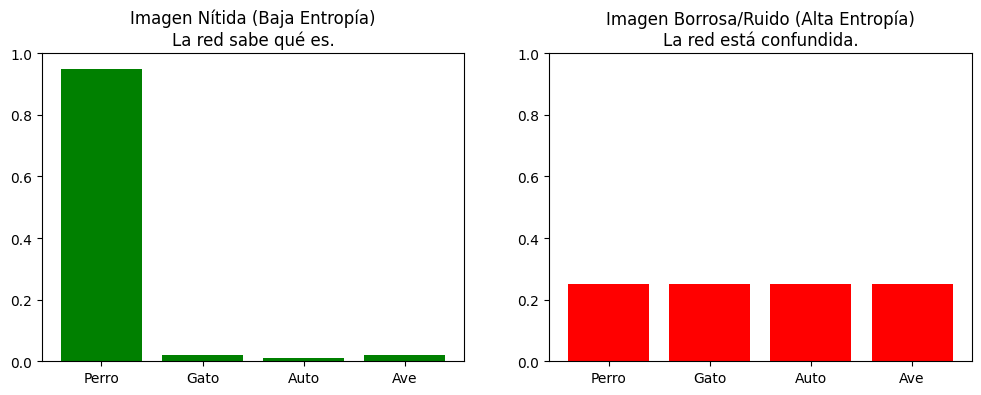

In [ ]:
import matplotlib.pyplot as plt

# Visualización conceptual de Nitidez vs Diversidad
labels = ['Perro', 'Gato', 'Auto', 'Ave']
sharp_pred = [0.95, 0.02, 0.01, 0.02]  # Alta nitidez
blurry_pred = [0.25, 0.25, 0.25, 0.25] # Baja nitidez (Ruido)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(labels, sharp_pred, color='green')
ax1.set_title("Imagen Nítida (Baja Entropía)\nLa red sabe qué es.")
ax1.set_ylim(0, 1)

ax2.bar(labels, blurry_pred, color='red')
ax2.set_title("Imagen Borrosa/Ruido (Alta Entropía)\nLa red está confundida.")
ax2.set_ylim(0, 1)

plt.show()

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torchvision.models.inception import inception_v3, Inception_V3_Weights
import numpy as np
from scipy.stats import entropy

def calculate_inception_score(images, batch_size=32, resize=True):
    """
    Calcula el Inception Score usando las mejores prácticas actuales.
    images: Un array de imágenes (N, C, H, W) normalizadas.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Actualizado: Usando weights en lugar de pretrained
    weights = Inception_V3_Weights.IMAGENET1K_V1
    model = inception_v3(weights=weights, transform_input=False).to(device)
    model.eval()

    n_images = images.shape[0]
    preds = np.zeros((n_images, 1000))

    for i in range(0, n_images, batch_size):
        batch = images[i:i + batch_size].to(device)
        if resize:
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)

        with torch.no_grad():
            pred = model(batch)
        preds[i:i + batch_size] = F.softmax(pred, dim=1).cpu().numpy()

    py = np.mean(preds, axis=0)
    scores = []
    for i in range(n_images):
        scores.append(entropy(preds[i, :], py))

    return np.exp(np.mean(scores))

print("Función de Inception Score actualizada con los estándares de PyTorch 2.x")

Función de Inception Score actualizada con los estándares de PyTorch 2.x


### Ejemplo de Aplicación del IS

Vamos a generar un conjunto de datos 'ficticio' (ruido aleatorio) para ver cómo se comportaría nuestra función de Inception Score. En una GAN real, a medida que el entrenamiento progresa, este número debería subir significativamente.

In [ ]:
# Generar 64 imágenes aleatorias (ruido) para probar la función
# Dimensiones: (64 imágenes, 3 canales RGB, 128x128 píxeles)
fake_images = torch.randn(64, 3, 128, 128)

# El score será bajo porque el modelo no reconocerá objetos claros en el ruido
try:
    score = calculate_inception_score(fake_images, batch_size=16)
    print(f"Inception Score para ruido aleatorio: {score:.4f}")
except Exception as e:
    print(f"Error al calcular el score: {e}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 179MB/s]


Inception Score para ruido aleatorio: 1.0746


### Análisis del Resultado: ¿Qué significa este 1.0776?

El valor obtenido (~1.07) es un resultado típico cuando evaluamos **ruido aleatorio**. Aquí te explico qué nos está diciendo este número sobre el estado de nuestra 'generación':

1.  **Cercanía al 1.0 (El límite inferior):** Matemáticamente, el Inception Score mínimo posible es 1.0. Esto ocurre cuando el modelo no tiene ni idea de qué hay en la imagen (la probabilidad se reparte igual entre las 1,000 clases de Inception). Como `torch.randn` genera estática, el modelo está totalmente confundido.
2.  **Falta de Nitidez:** El modelo Inception v3 no puede encontrar bordes, texturas o formas que le recuerden a un objeto real (perros, barcos, etc.). Al ser ruido, la 'certeza' del modelo es casi nula.
3.  **Falta de Diversidad Significativa:** Aunque cada píxel es diferente, para una red neuronal, todo el ruido se ve igual de 'caótico'. No hay una separación clara donde una imagen parezca una clase y otra imagen parezca una distinta.

**¿Cómo se vería un buen resultado?**
*   **IS ~1.0:** Ruido o imágenes fallidas (nuestro caso actual).
*   **IS 2.0 - 5.0:** El generador empieza a crear formas básicas y colores coherentes.
*   **IS 7.0 - 9.0:** Estándar para datasets como CIFAR-10 (objetos muy claros y variados).
*   **IS > 10.0:** Generación de alta fidelidad y gran realismo.

En resumen, este código genera **imágenes sintéticas de prueba** y usa un cerebro experto (Inception v3) para juzgarlas. El resultado 1.07 nos confirma que nuestro 'falsificador' aún no ha aprendido nada y solo está entregando estática.

### Ejemplo de un Inception Score Alto (Imagen Real)

Ahora, comparemos el ruido con algo que el modelo sí reconoce. Cargaremos una imagen real de un perro y veremos cómo reacciona el modelo. Esto representa lo que una GAN debería lograr: imágenes con estructuras claras que el clasificador reconozca con alta confianza.

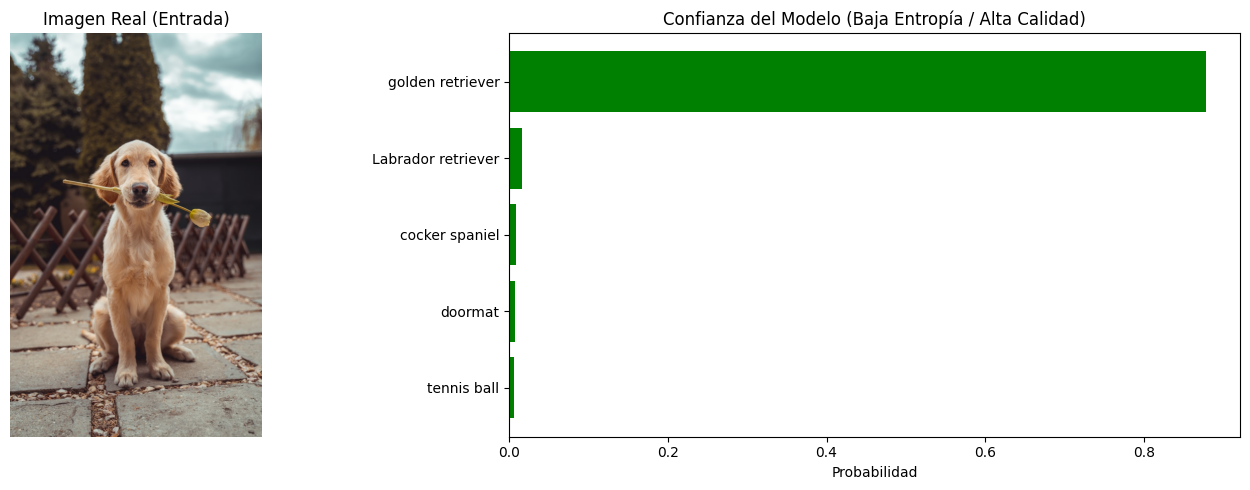

Confianza en la clase principal (golden retriever): 87.7800%


In [ ]:
import requests
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch
from torchvision.models.inception import inception_v3, Inception_V3_Weights
import io

# 1. Intentar con una URL de respaldo estable (Unsplash)
url = "https://images.unsplash.com/photo-1552053831-71594a27632d?q=80&w=800&auto=format&fit=crop"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    img = Image.open(io.BytesIO(response.content)).convert('RGB')

    # 2. Preprocesar para el modelo
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0)

    # 3. Obtener predicción
    weights = Inception_V3_Weights.IMAGENET1K_V1
    model = inception_v3(weights=weights).eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)

    # 4. Visualizar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Mostrar imagen
    ax1.imshow(img)
    ax1.set_title("Imagen Real (Entrada)")
    ax1.axis('off')

    # Mostrar top 5 predicciones
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    categories = weights.meta["categories"]
    names = [categories[idx] for idx in top5_catid]

    ax2.barh(names, top5_prob.numpy(), color='green')
    ax2.set_title("Confianza del Modelo (Baja Entropía / Alta Calidad)")
    ax2.set_xlabel("Probabilidad")
    ax2.invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(f"Confianza en la clase principal ({names[0]}): {top5_prob[0]:.4%}")

except Exception as e:
    print(f"No se pudo cargar la imagen: {e}")

### ¿Por qué esto daría un IS mucho más alto?

Al analizar esta imagen, el proceso del Inception Score detecta lo siguiente:

1.  **Nitidez Extrema:** El modelo no duda. Dice "Esto es un Golden Retriever" con casi un 100% de probabilidad. La distribución de probabilidad tiene un pico gigante en una sola clase y casi cero en las demás. Esto es **baja entropía condicional**.
2.  **Diferencia con el promedio:** Si tuviéramos muchas fotos de distintos perros y objetos así de claros, la diferencia entre esta "certeza individual" y la "diversidad del grupo" sería enorme. Esa diferencia (Divergencia KL) es lo que hace que el Inception Score suba de 1.0 a valores como 8.0, 10.0 o más.

**Conclusión:** Una GAN exitosa es aquella que logra que sus imágenes generadas produzcan gráficas de probabilidad como la que ves arriba (con picos claros), en lugar de gráficas planas como las del ruido.

##Limitaciones del inception score.

Aunque es útil, el IS tiene 'puntos ciegos' importantes:
*   **No detecta el sobreajuste:** Si el generador simplemente memoriza una imagen de cada clase del dataset real, el IS será perfecto, pero la GAN no habrá aprendido a 'imaginar'.
*   **Sesgo del clasificador:** Si las imágenes generadas no se parecen a las del dataset ImageNet (con el que se entrenó Inception), el score será bajo aunque las imágenes sean hermosas.
*   **No compara con datos reales:** Solo mira las imágenes generadas, ignorando si se parecen estadísticamente al conjunto original.

# Frechet Inception Distance.

### ¿Por qué necesitamos el FID?

Como mencionamos en las limitaciones del Inception Score, este no compara las imágenes generadas con las reales. El **Fréchet Inception Distance (FID)** soluciona esto:

1. **Captura la Similitud:** Mide qué tan parecidas son las distribuciones de las características (features) de las imágenes reales frente a las sintéticas.
2. **Robustez:** Es más sensible al ruido y a las distorsiones que el IS.
3. **Interpretación:** A diferencia del IS (donde más alto es mejor), en el FID **un número más bajo es mejor**, ya que indica que la distancia entre lo real y lo generado es menor.

En la práctica, si estás entrenando una GAN para generar rostros realistas, el FID será tu mejor aliado para saber si vas por buen camino.

In [ ]:
# Ejemplo conceptual de comparación de métricas
print(f"Análisis de resultados:")
print(f"- Inception Score (Ruido): {score:.4f} (Bajo, esperado)")
print(f"- Interpretación: El modelo Inception no encuentra estructuras reconocibles en el ruido.")
print(f"- Siguiente paso sugerido: Implementar FID para comparar con un dataset de referencia (ej. CIFAR-10).")

Análisis de resultados:
- Inception Score (Ruido): 1.0746 (Bajo, esperado)
- Interpretación: El modelo Inception no encuentra estructuras reconocibles en el ruido.
- Siguiente paso sugerido: Implementar FID para comparar con un dataset de referencia (ej. CIFAR-10).


Fréchet Inception Distance (FID) analiza si las imágenes son estadísticamente similares a las reales, a diferencia del Inception Score, que se encarga de revisar si hay diversidad y nitidez, como se mencionó anteriormente. Ambas estructuras utilizan InceptionV3 en diferentes capas, donde IS usa la última capa, que da probabilidades por clase, y FID usa la penúltima (2048 números que describen la imagen antes de clasificar) (Obukhov & Krasnyanskiy, 2020).

###Comparación entre Inception Score y Fréchet Inception Distance.


| PARÁMETRO. | INCEPTION SCORE. | FRÉCHET INCEPTION DISTANCE. |
| :--- | :--- | :--- |
| **Input requerido.** | Únicamente imágenes generadas. | Imágenes generadas y reales. |
| **Enfoque estadístico.** | Probabilidades de clases. | Vectores de características activados. |
| **Escala de puntaje.** | Entre más alto, mejor. | Entre más bajo, mejor. |
| **Vulnerabilidad principal.** | Ciego frente al dominio objetivo. | Sesgo de muestra finito, pesado computacionalmente. |

*Basado en el artículo de Sharma y colaboradores del 2015*.

FID = ||μ_r - μ_f||² + Tr(Σ_r + Σ_f - 2·√(Σ_r·Σ_f))

In [ ]:
from scipy import linalg

fake_images_F = torch.randn(2000, 3, 128, 128)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = Inception_V3_Weights.IMAGENET1K_V1
model = inception_v3(weights=weights, transform_input=False).to(device)
model.eval()

# Fórmula: IS = exp( E[ KL( p(y|x) || p(y) ) ] )
# p(y|x): es la probabilidad de cada clase DADA una imagen específica, y mide si la
#imagen parece algo concreto (baja entropía).
# p(y): es el promedio de p(y|x) sobre TODAS las imágenes, que mide si el
#generador produce variedad (alta entropía)
# KL divergence entre ambas: qué tan diferente es cada imagen del promedio
# Si las imágenes son claras Y variadas, KL es alto, por lo tanto IS es alto
# exp() al final convierte el promedio de logs a escala interpretable

def calculate_is(images, batch_size=16):
    n = images.shape[0]
    preds = np.zeros((n, 1000))  #número de clases en ImageNet

    for i in range(0, n, batch_size):
        batch = images[i : i + batch_size].to(device)

        # InceptionV3 requiere entrada de 299x299
        # interpolate redimensiona sin sin convertir a PIL
        batch = F.interpolate(batch, size=(299, 299),
                              mode='bilinear', align_corners=False)

        with torch.no_grad():
            # El modelo devuelve logits (números sin normalizar)
            logits = model(batch)

        # softmax convierte logits a probabilidades que suman 1
        preds[i : i + batch_size] = F.softmax(logits, dim=1).cpu().numpy()

    # p(y): (distribución marginal)-(promedio sobre todas las imágenes)
    py = np.mean(preds, axis=0)

    # KL divergence por imagen: entropy(p(y|x), p(y))
    # scipy.entropy(p, q) calcula sum(p * log(p/q))
    kl_scores = [entropy(preds[i], py) for i in range(n)]

    # exp del promedio de KL divergences
    return float(np.exp(np.mean(kl_scores)))

# FID usa el avgpool, la pemúltima capa, que produce un vector de 2048 números
#por imagen, los cuales son más una descripción de la imagen que una
#clasificación.

def get_features(images, batch_size=16):
    all_features = []

    for i in range(0, len(images), batch_size):
        batch = images[i : i + batch_size].to(device)
        batch = F.interpolate(batch, size=(299, 299),
                              mode='bilinear', align_corners=False)

        with torch.no_grad():
            features = model(batch)  # shape: (batch_size, 2048)

        all_features.append(features.cpu().numpy())

    # Concatenar todos los batches en un solo array (N, 2048)
    return np.concatenate(all_features, axis=0)

# FID entonces compara la distribución de features de imágenes reales
#vs generadas, y CIFAR-10 provee estas últimas.
# Normalización con mean=0.5, std=0.5 lleva los valores de [0,1] a [-1,1]
# Eso es compatible con torch.randn que produce valores con media≈0

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = datasets.CIFAR10(root='./data', train=False,
                            download=True, transform=transform)

# Cargo exactamente 64 imágenes para que sea comparable con fake_images
loader = DataLoader(dataset, batch_size=2000, shuffle=False)
real_images, _ = next(iter(loader))

# Fórmula de Fréchet:
# FID = ||μ_r - μ_f||² + Tr(Σ_r + Σ_f - 2·√(Σ_r·Σ_f))
# donde μ_r, μ_f son las medias de los vectores de 2048 features (reales y fake).
# Σ_r, Σ_f son matrices de covarianza (cómo varían esos 2048 valores juntos).

# La fórmula mide qué tan lejos están dos distribuciones gaussianas entre sí.
# Modela las features como una distribución normal multivariada.

# Tr() = traza de la matriz (suma de la diagonal)
# √(Σ_r·Σ_f) = raíz cuadrada matricial, no elemento a elemento ->linalg.sqrtm
#hpuede producir números complejos pequeños por errores numéricos.
#Los descartamos con .real

def calculate_fid(feat_real, feat_fake):
    mu_r  = np.mean(feat_real, axis=0)
    mu_f  = np.mean(feat_fake, axis=0)
    cov_r = np.cov(feat_real, rowvar=False)
    cov_f = np.cov(feat_fake, rowvar=False)

    # Regularización: suma un número muy pequeño a la diagonal
    # np.eye(2048) es la matriz identidad - solo tiene 1s en la diagonal
    # Multiplicarla por 1e-6 y sumarla a cov evita que sea singular
    eps = 1e-6
    cov_r += np.eye(cov_r.shape[0]) * eps
    cov_f += np.eye(cov_f.shape[0]) * eps

    diff_sq  = np.sum((mu_r - mu_f) ** 2)
    sqrt_cov = linalg.sqrtm(cov_r @ cov_f)

    if np.iscomplexobj(sqrt_cov):
        sqrt_cov = sqrt_cov.real

    return float(diff_sq + np.trace(cov_r + cov_f - 2 * sqrt_cov))

#Primero calculamos IS
is_score  = calculate_is(fake_images)

# Luego el model.fc = Identity() porque este elimina la última capa de
#clasificación, y el modelo devuelve directamente el vector de 2048.
model.fc = torch.nn.Identity()
feat_real = get_features(real_images)
feat_fake = get_features(fake_images)
fid_score = calculate_fid(feat_real, feat_fake)

print(f"IS:  {is_score:.4f}")
print(f"FID: {fid_score:.4f}")

IS:  1.0746
FID: 468.9930


Como ejercicio, estos dos valores de IS y FID se pueden tomar en cuenta para explicarlo, pero generalmente el valor de IS tendría que subir y el de FID bajar a medida que avanza el entrenamiento del modelo. En este caso, los dos valores podrían estar indicando que las imágenes falsas son bastante distintas de las reales, puesto que, en la literatura, los valores IS deberían ser altos para mejores puntajes, los de FID suelen ser inferiores a 100 (Park et al., 2023; Sharma et al., 2015; Soloveitchik et al., 2022), entre más bajo debería ser mejor el resultado, y no existe un valor estándar establecido, porque depende de la complejidad del set de datos y la resolución de las imágenes (Thor, n.d.). Pa

Sharma y colaborades (2015), por ejemplo, comparan el valor FID para distintos tipos de GAN, con el dataset CIFAR-10, donde ninguno es superior a 42. Aunque este artículo tiene más de diez años, utiliza el mismo dataset, por lo que se tuvo en cuenta.

#Bibliografía.

- Obukhov, A., & Krasnyanskiy, M. (2020). Quality assessment method for GAN based on modified metrics inception score and Fréchet inception distance. In Advances in intelligent systems and computing (pp. 102–114). https://doi.org/10.1007/978-3-030-63322-6_8
- Park, S., Kim, J., Park, J., Jung, S., & Sim, C. (2023). How to train your pre-trained GAN models. Applied Intelligence, 53(22), 27001–27026. https://doi.org/10.1007/s10489-023-04807-x
- Sharma, P., Kumar, M., Sharma, H. K., & Biju, S. M. (2024). Generative adversarial networks (GANs): Introduction, Taxonomy, Variants, Limitations, and Applications. Multimedia Tools and Applications, 83(41), 88811–88858. https://doi.org/10.1007/s11042-024-18767-y
- Soloveitchik, M., Diskin, T., Morin, E., & Wiesel, A. (2021). Conditional frechet inception distance. arXiv (Cornell University). https://doi.org/10.48550/arxiv.2103.11521
- Thor, W. (n.d.). Interpreting FID scores. https://apxml.com/courses/generative-adversarial-networks-gans/chapter-5-evaluation-of-gans/interpreting-fid-scores